In [4]:
# Import libraries
%reload_ext autoreload
%autoreload 2

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from IPython.display import display, HTML, Latex, Image, Video
from IPython.display import Markdown as md
from IPython.core.magic import register_cell_magic
from tabulate import tabulate
from sklearn.linear_model import LinearRegression
import mercury as mr
import datetime

@register_cell_magic
def markdown(line, cell):
    return md(cell.format(**globals()))

last_friday = datetime.date.today() - pd.offsets.Week(weekday=4)


pcourse_name     = "Course Name"
course_name        = "PHYS 2125 (15921)"
pcourse_semester = "Semester"
course_semester    = "Spring 2025"
pstudent_name    = "What is Your Name?"
student_name       = "Sir Lancelot of Camelot"
plab_date        = "Lab Date"
lab_date           = last_friday.strftime("%Y-%m-%d")
plab_number      = "Lab Number"
lab_number         = "11"
plab_name        = "Lab Name"
lab_name           = "Projectile 1 (Symmetric Parabola)"
plab_objective   = "Lab Objective"
lab_objective      = "To determine the speed of the projectile."
pdata_filename   = "Data filename"
data_filename      = 'lab' + lab_number + '.csv'
pgraph_x_label   = "Label for graph x-axis"
graph_x_label      = 'Independent variable'
pgraph_y_label   = "Label for graph y-axis"
graph_y_label      = 'Dependent variable'
pgraph_label     = "Label for graph"
graph_label        = graph_y_label + " vs " + graph_x_label
pdata_columns    = "Data Columns"
data_columns       = ["$f (Hz)$", "$\\lambda_1 (cm)$", "$\\lambda_2 (cm)$", "$\\lambda (m)$", "$\\frac{1}{\\lambda} (m^{-1})$", "$v (\\frac{m}{s})$"];
pdata_index      = "Index Column"
data_index         = 0
pquestion_1      = "A child throws a ball from 4.0 m height, at a velocity of 29.4 m/s at an initial angle of 60.0° with respect to the vertical. What is the Range of the during its trajectory from ground?"
question_1         = "To seek the holy grail."
pquestion_2      = "A cannon barrel is elevated 35º above the horizontal. It fires a ball with a speed of 300 m/s. What is the range of the projectile and the height does the ball reach?"
question_2         = "Blue."

# TODO: Add a field to select columns to compute average for
pcalc_average    = "Compute average for fields"
# TODO: Add a field to compute Std Dev for
pcalc_deviation  = "Compute standard deviation for fields"

# TODO: Add a field to select columns to compute average for
calc_average    = 1
# TODO: Add a field to compute Std Dev for
calc_deviation  = 1

In [2]:
%autoreload 2

app             = mr.App(title="Lab " + defNum + " - " + defName, description="Lab report for " + defCourse + " " + defSem + " Lab " + defNum + ".")
course_name     = mr.Text(label=pcourse_name,     value=course_name,     rows=1)
course_semester = mr.Text(label=pcourse_semester, value=course_semester, rows=1)
student_name    = mr.Text(label=pstudent_name,    value=student_name,    rows=1)
lab_date        = mr.Text(label=plab_date,        value=lab_date,        rows=1)
lab_number      = mr.Text(label=plab_number,      value=lab_number,      rows=1)
lab_name        = mr.Text(label=plab_name,        value=lab_name,        rows=1)
lab_objective   = mr.Text(label=plab_name,        value=lab_objective,   rows=1)
data_filename   = mr.Text(label=pdata_filename,   value=data_filename,   rows=1)
graph_x_label   = mr.Text(label=pgraph_x_label,   value=graph_x_label,   rows=1)
graph_y_label   = mr.Text(label=pgraph_y_label,   value=graph_y_label,   rows=1)
graph_label     = mr.Text(label=pgraph_label,     value=graph_label,     rows=1)
data_columns    = mr.Text(label=pdata_columns,    value=data_columns,    rows=1)
data_index      = mr.Text(label=pdata_index,      value=data_index,      rows=1)
question_1      = mr.Text(label=pquestion_1,      value=question_1,      rows=1)
question_2      = mr.Text(label=pquestion_2,      value=question_2,      rows=1)
question_3      = mr.Text(label=pquestion_3,      value=question_3,      rows=1)



discuss   = mr.Text(value="Discussion",             label="Discuss", rows=5)
file      = mr.File(label="Data file upload",       max_file_size="10MB")

# TODO: Add column names to the Mercury form
# TODO: Add column index to the Mercury form


if file.filepath is not None:
    df = pd.read_csv(file.filepath, names=columns, header=0)
else:
    df = pd.read_csv(fileName, names=columns, header=0)

# Remove the last row with the empty index
df = df.drop(df.tail(1).index)

# Save this for the graph
df_graph = df;

# Mean and StdDev across the board
mean = df.mean()
deviation = df.std(ddof=0)
trend = np.polyfit(df[columns[4]], df[columns[0]], 1)  # 1 for linear trendline
trend_slope, trend_intercept = trend

v_t = mean[columns[5]];
v_t_dev = deviation[columns[5]];
v_g = trend_slope
v_diff = abs( v_g - v_t ) / ( ( v_t + v_g ) / 2 )

df = df.set_index(columns[colIdx])

# Add the average value of u_k
df.loc['Average'] = {
    columns[1]: np.nan,
    columns[2]: np.nan,
    columns[3]: np.nan,
    columns[4]: np.nan,
    columns[5]: v_t
};
# Add the standard devation value of u_k
df.loc['StdDev'] = {
    columns[1]: np.nan,
    columns[2]: np.nan,
    columns[3]: np.nan,
    columns[4]: np.nan,
    columns[5]: v_t_dev
};

# Formatting
#df[columns[2]] = df.apply(lambda row: f"{row[columns[1]]:.4f}", axis=1)
#df[columns[2]] = df.apply(lambda row: f"{row[columns[2]]:.4f}", axis=1)
#df[columns[3]] = df.apply(lambda row: f"{row[columns[3]]:.4f}", axis=1)
#df[columns[4]] = df.apply(lambda row: f"{row[columns[4]]:.4f}", axis=1)
#df[columns[5]] = df.apply(lambda row: f"{row[columns[5]]:.4f}", axis=1)

# Save this for the table
df_table = df.fillna('');

# Make some strings
v_t_str = str("%.3f" % round(v_t, 3))
v_t_dev_str = str("%.3f" % round(v_t_dev, 3))
v_g_str = str("%.3f" % round(v_g, 3))
v_diff_str = str("%.3f" % round(v_diff, 3))
trend_slope_str = str("%.3f" % round(trend_slope, 3))
trend_intercept_str = str("%.3f" % round(trend_intercept, 3))

In [3]:
%%markdown

# Lab {labNum.value}: {labName.value}
Name: **{name.value}** \
Class: **{course.value}** \
Date: **{date.value}**

<p style="page-break-after:always;"></p>

## Objective

{labObj.value}


# Lab 10: Waves
Name: **Waves** \
Class: **PHYS 2125 (15921)** \
Date: **2025-03-21**

<p style="page-break-after:always;"></p>

## Objective

To determine the speed of a wave on string.


## Equipment

This experiment was simulated using 

<p style="page-break-after:always;"></p>

## Theory

A projectile is launced with an angle $\theta$, with maximum height $r4}

![Image of a wave with the amplitude and wavelength (λ) labeled.](https://docs.google.com/drawings/d/e/2PACX-1vT0DK-vBRcIvk4xQrTVYytFyBY1kfX3woWLR7xfOlGuckIlPgHEmEnEXu5cj-ePxsxeumvrnJz_cKDo/pub?w=481 "Wavelength and Amplitude")

$\lambda$ is the wavelength ($m$),

$A$ is the amplitude of the wave.

In general...

$v = f \lambda$

where

$v$ is the speed of the wave ($\frac{m}{s})$, and

$f$ is the frequency of the wave ($Hz$).

For a wave on a string, the speed of the wave can instead be described as

$v = \sqrt{\dfrac{m}{\mu}}$

where $\mu$ is the linear density of the string ($kg/m$).

$\mu = \dfrac{mass\; of\; the\; string}{length\; of\; the\; string}$.

Rearranging our first equation yields the following, which we will graph below.

$f = v \cdot \dfrac{1}{\lambda}$

<p style="page-break-after:always;"></p>

## Procedure

The following procedure was followed.

### Initial Setup

The pendulum was constructed as follows.

1. The simulation was loaded.
1. The "oscillation" mode was selected.
1. Tension was set to maximum.
1. All damping was removed.
1. Both ends were fixed.

### Trial (completed twice for each frequency)

1. The desired frequency was selected.
2. The oscillation was started and then quickly paused once a full wavelength had been emitted.
3. The wavelength was measured and recorded.

<p style="page-break-after:always;"></p>

## Data

In [4]:

%autoreload 2
# Print the data table
mr.Table(data=df_table, width="25px")
#HTML(df_table.to_html(notebook=True,col_space=10))

## Calculations

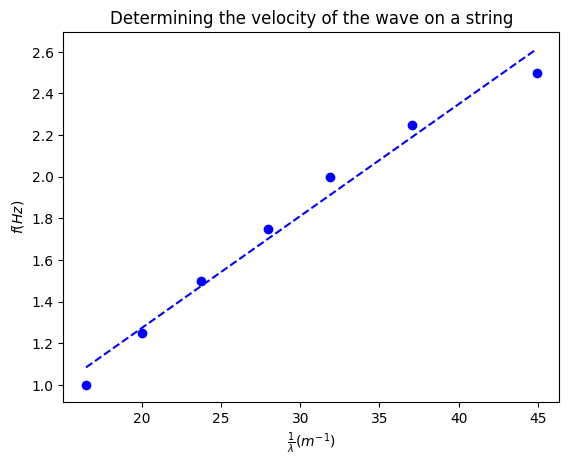

In [5]:
# Plot the measurements
plt.scatter(df_graph[columns[4]], df_graph[columns[0]], color="blue", marker="o");

# Plot the trendline
fit = np.polyval(trend, df_graph[columns[4]])
plt.plot(df_graph[columns[4]], fit, color="blue", linestyle="--")

# Add labels w LaTeX support
plt.xlabel(columns[4]);
plt.ylabel(columns[0]);
plt.title(g_title.value);
plt.rcParams['text.usetex'] = True;
plt.rcParams['font.family'] = 'serif';

# Show the graph
plt.show();

In [6]:
%%markdown

Using the least squares method a trend line is fit to the data with *slope* {trend_slope_str} and *$y$-intercept* {trend_intercept_str}, resulting in the equation $ y = {trend_slope_str} x + {trend_intercept_str} $.

## Results

The average value of $v$ was calculated as ${v_t_str}\; \pm\; {v_t_dev_str}$.

Using the least squares method $v$ was calculated as ${v_g_str}$.

These two values differ by ${v_diff_str}$%.

## Discussion

{discuss.value}


Using the least squares method a trend line is fit to the data with *slope* 0.054 and *$y$-intercept* 0.199, resulting in the equation $ y = 0.054 x + 0.199 $.

## Results

The average value of $v$ was calculated as $0.061\; \pm\; 0.002$.

Using the least squares method $v$ was calculated as $0.054$.

These two values differ by $0.129$%.

## Discussion

Discussion
